# ALNS hyperparameter analysis


## Imports

In [12]:
import sys
import os

root = os.path.dirname(os.getcwd())
sys.path.append(root)

import time
import numpy as np
import matplotlib.pyplot as plt

from cvrptw.parser import parse_solomon
from cvrptw.heuristics.alns import solve


## Configuration

Note: the best known minimises vehicles first and then distance while my solve function
minimises only distance so the gap can
be negative ie shorter distance but more vehicles which is why we also record
the vehicle count


In [13]:
INSTANCES = {
    'c101': '../data/solomon/c101.txt',
    'r101': '../data/solomon/r101.txt',
    'rc101': '../data/solomon/rc101.txt',
    'r201': '../data/solomon/r201.txt',
    'rc201': '../data/solomon/rc201.txt',
}
BEST_KNOWN = {
    'c101': 828.94,
    'r101': 1650.80,
    'rc101': 1696.95,
    'r201': 1252.37,
    'rc201': 1406.94,
}

SEEDS = [0, 1, 2]


In [14]:
def gap_to_ref(distance, ref):
    if ref is None:
        return float('nan')
    return (distance - ref) / ref * 100


def run(name, instance, seeds, **params):
    ref = BEST_KNOWN.get(name)
    records = []
    for seed in seeds:
        start = time.perf_counter()
        best, stopped_at = solve(instance, seed=seed, **params)
        total_time = time.perf_counter() - start
        distance = best.distance()
        records.append({
            'instance': name,
            'seed': seed,
            'distance': distance,
            'vehicles': len(best.routes),
            'gap': gap_to_ref(distance, ref),
            'runtime': total_time,
            'stopped_at': stopped_at,
            **params,
        })
    return records

def plot_time_gap(records, param_key, title):
    values = sorted(set(r[param_key] for r in records))
    times = [np.nanmean([r['runtime'] for r in records if r[param_key] == v]) for v in values]
    gaps = [np.nanmean([r['gap'] for r in records if r[param_key] == v]) for v in values]

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(times, gaps, c=values, cmap='viridis', s=90)
    for t, g, v in zip(times, gaps, values):
        ax.annotate(str(v), (t, g), textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xlabel('mean runtime (s)')
    ax.set_ylabel('mean gap to optimum (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, label=param_key)
    plt.show()

In [15]:
def plot_gap_vs_value(records, param_key, values, title):
    # gap vs parameter value, one line per instance, mean +/- std over seeds
    fig, ax = plt.subplots(figsize=(8, 5))
    for name in INSTANCES:
        means = [np.nanmean([r['gap'] for r in records if r['instance'] == name and r[param_key] == v]) for v in values]
        stds = [np.nanstd([r['gap'] for r in records if r['instance'] == name and r[param_key] == v]) for v in values]
        ax.errorbar(values, means, yerr=stds, marker='o', capsize=3, label=name)
    ax.set_xlabel(param_key)
    ax.set_ylabel('mean gap to optimum (%)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


## Parameter tunning
### First one parametter at a time for a simple aproach to know good parameters and then a grid search to get the finnal parameters
- Destruction size



In [16]:
DESTRUCTION_SIZES = [5, 10, 15, 20, 30, 40]
ITERATIONS = 300

n_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for destruction_size in DESTRUCTION_SIZES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, n=destruction_size)
        n_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} n={destruction_size} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 n=5 gap_mean=20.16856961934234%  dist_mean=996.1253410025765  time_mean=0.9964124000010391s  stop_mean=282.0
c101 n=10 gap_mean=14.515921175812538%  dist_mean=949.2682769947805  time_mean=1.5341955999222894s  stop_mean=287.6666666666667
c101 n=15 gap_mean=3.9981365479817192%  dist_mean=862.0821531008397  time_mean=1.6435692667340238s  stop_mean=297.3333333333333
c101 n=20 gap_mean=5.8256673391883425%  dist_mean=877.231286841468  time_mean=1.7277119998664905s  stop_mean=274.6666666666667
c101 n=30 gap_mean=2.668865895212712%  dist_mean=851.0632969517764  time_mean=2.460671366735672s  stop_mean=240.0
c101 n=40 gap_mean=-0.0003779594622134563%  dist_mean=828.9368669428341  time_mean=3.112870700036486s  stop_mean=216.33333333333334
r101 n=5 gap_mean=8.45208328843148%  dist_mean=1790.3269909254268  time_mean=0.521496000001207s  stop_mean=300.0
r101 n=10 gap_mean=4.109553799841816%  dist_mean=1718.640514127789  time_mean=0.7518338665831834s  stop_mean=260.3333333333333
r101 n=15 gap_mea

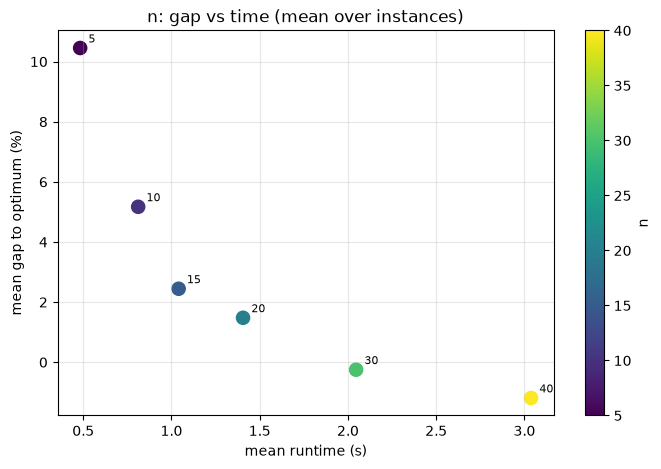

In [17]:
plot_time_gap(n_list, 'n', 'n: gap vs time (mean over instances)')


Probably look between 25-30

- coling (cooling rate)

In [18]:
COLING_VALUES = [0.99, 0.995, 0.999]
ITERATIONS = 300

coling_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for coling in COLING_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, coling=coling)
        coling_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} coling={coling} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 coling=0.99 gap_mean=-0.0003779594622180279%  dist_mean=828.936866942834  time_mean=1.2549652332284797s  stop_mean=276.0
c101 coling=0.995 gap_mean=5.8256673391883425%  dist_mean=877.231286841468  time_mean=1.0657013666350394s  stop_mean=274.6666666666667
c101 coling=0.999 gap_mean=1.210988986943117%  dist_mean=838.9783721083663  time_mean=1.0596485000569373s  stop_mean=277.3333333333333
r101 coling=0.99 gap_mean=1.3853365555089185%  dist_mean=1673.6691358583412  time_mean=1.2366374333699544s  stop_mean=300.0
r101 coling=0.995 gap_mean=1.6701223562698402%  dist_mean=1678.3703798573024  time_mean=1.3030220333797236s  stop_mean=297.3333333333333
r101 coling=0.999 gap_mean=2.2694901148255577%  dist_mean=1688.2647428155403  time_mean=0.9231321000649283s  stop_mean=279.3333333333333
rc101 coling=0.99 gap_mean=-0.03530877391269951%  dist_mean=1696.3508277610883  time_mean=1.3541031000980486s  stop_mean=299.3333333333333
rc101 coling=0.995 gap_mean=-0.17029249080361597%  dist_mean=1694.0

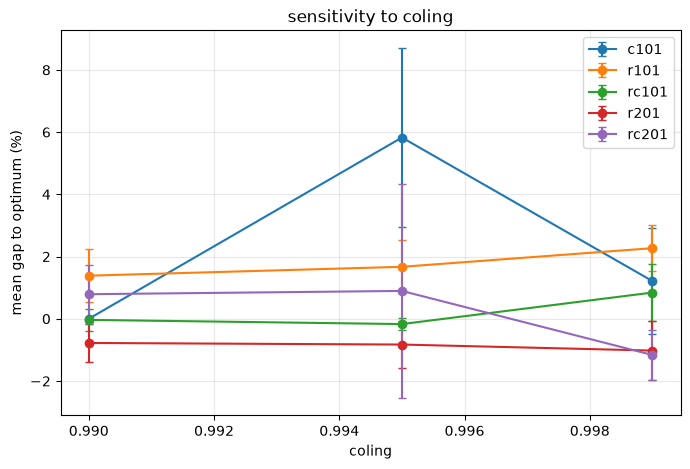

In [19]:
plot_gap_vs_value(coling_list, 'coling', COLING_VALUES, 'sensitivity to coling')


- t_factor (initial temperature)

In [20]:
T_FACTOR_VALUES = [0.01, 0.05, 0.1, 0.2]
ITERATIONS = 300

t_factor_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for t_factor in T_FACTOR_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, t_factor=t_factor)
        t_factor_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} t_factor={t_factor} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 t_factor=0.01 gap_mean=5.6273184059160934%  dist_mean=875.5870931940009  time_mean=1.8842051333437364s  stop_mean=284.3333333333333
c101 t_factor=0.05 gap_mean=5.8256673391883425%  dist_mean=877.231286841468  time_mean=1.829657766657571s  stop_mean=274.6666666666667
c101 t_factor=0.1 gap_mean=4.304187199088305%  dist_mean=864.6191293681227  time_mean=1.7113411666359752s  stop_mean=276.0
c101 t_factor=0.2 gap_mean=-0.0003779594622180279%  dist_mean=828.936866942834  time_mean=2.1462778333419315s  stop_mean=297.0
r101 t_factor=0.01 gap_mean=1.2200980517912992%  dist_mean=1670.9413786389707  time_mean=1.7926520666417975s  stop_mean=272.0
r101 t_factor=0.05 gap_mean=1.6701223562698402%  dist_mean=1678.3703798573024  time_mean=1.4079561666585505s  stop_mean=297.3333333333333
r101 t_factor=0.1 gap_mean=1.6211186927045012%  dist_mean=1677.561427379166  time_mean=1.2893922334381689s  stop_mean=271.3333333333333
r101 t_factor=0.2 gap_mean=1.9840155792640026%  dist_mean=1683.55212918249  ti

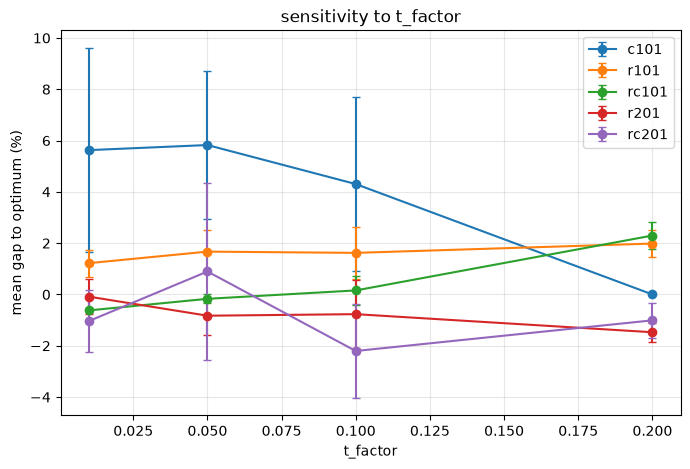

In [21]:
plot_gap_vs_value(t_factor_list, 't_factor', T_FACTOR_VALUES, 'sensitivity to t_factor')


- new_percentage (reaction factor)

In [22]:
NEW_PERCENTAGE_VALUES = [5, 15, 30, 50]
ITERATIONS = 300

new_percentage_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for new_percentage in NEW_PERCENTAGE_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, new_percentage=new_percentage)
        new_percentage_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} new_percentage={new_percentage} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 new_percentage=5 gap_mean=2.528492144489714%  dist_mean=849.8996827825331  time_mean=1.0476113666469853s  stop_mean=277.3333333333333
c101 new_percentage=15 gap_mean=5.8256673391883425%  dist_mean=877.231286841468  time_mean=1.2808867999507736s  stop_mean=274.6666666666667
c101 new_percentage=30 gap_mean=5.285037515519155%  dist_mean=872.7497899811445  time_mean=1.0791481666577358s  stop_mean=277.3333333333333
c101 new_percentage=50 gap_mean=2.528492144489714%  dist_mean=849.8996827825331  time_mean=1.9170921666858096s  stop_mean=277.3333333333333
r101 new_percentage=5 gap_mean=1.633087983639329%  dist_mean=1677.759016433918  time_mean=1.883815766700233s  stop_mean=300.0
r101 new_percentage=15 gap_mean=1.6701223562698402%  dist_mean=1678.3703798573024  time_mean=1.541543533327058s  stop_mean=297.3333333333333
r101 new_percentage=30 gap_mean=1.5238354692055645%  dist_mean=1675.9554759256455  time_mean=1.5900879999777924s  stop_mean=300.0
r101 new_percentage=50 gap_mean=1.6594891324

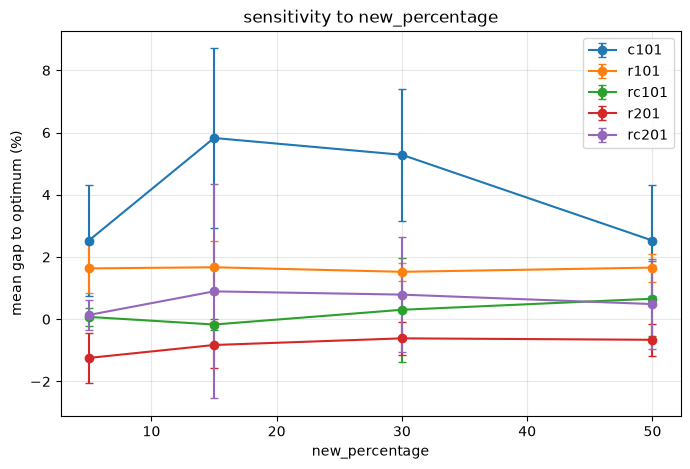

In [23]:
plot_gap_vs_value(new_percentage_list, 'new_percentage', NEW_PERCENTAGE_VALUES, 'sensitivity to new_percentage')


- iterations_update

In [24]:
ITERATIONS_UPDATE_VALUES = [50, 100, 200]
ITERATIONS = 300

iterations_update_list = []
for name, path in INSTANCES.items():
    instance = parse_solomon(path)
    for iterations_update in ITERATIONS_UPDATE_VALUES:
        recs = run(name, instance, SEEDS, iterations=ITERATIONS, iterations_update=iterations_update)
        iterations_update_list+=recs
        gaps = [r['gap'] for r in recs]
        print(f'{name} iterations_update={iterations_update} gap_mean={np.nanmean(gaps)}%  '
              f'dist_mean={np.mean([r["distance"] for r in recs])}  '
              f'time_mean={np.mean([r["runtime"] for r in recs])}s  '
              f'stop_mean={np.mean([r["stopped_at"] for r in recs])}')


c101 iterations_update=50 gap_mean=1.3911162176844432%  dist_mean=840.4715187748734  time_mean=2.147373433380077s  stop_mean=291.3333333333333
c101 iterations_update=100 gap_mean=5.8256673391883425%  dist_mean=877.231286841468  time_mean=1.5856127666775137s  stop_mean=274.6666666666667
c101 iterations_update=200 gap_mean=2.528492144489714%  dist_mean=849.8996827825331  time_mean=1.0413032000263531s  stop_mean=277.3333333333333
r101 iterations_update=50 gap_mean=1.7128813062182935%  dist_mean=1679.0762446030515  time_mean=1.4331179332608979s  stop_mean=288.0
r101 iterations_update=100 gap_mean=1.6701223562698402%  dist_mean=1678.3703798573024  time_mean=1.629048433387652s  stop_mean=297.3333333333333
r101 iterations_update=200 gap_mean=1.3349876116138955%  dist_mean=1672.837975492522  time_mean=1.2737206999833386s  stop_mean=300.0
rc101 iterations_update=50 gap_mean=0.7691401854891732%  dist_mean=1710.0019243776585  time_mean=0.9469392999696234s  stop_mean=230.66666666666666
rc101 itera

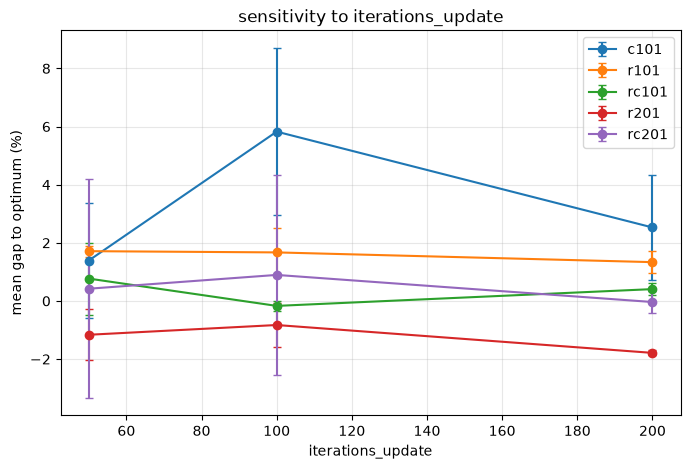

In [25]:
plot_gap_vs_value(iterations_update_list, 'iterations_update', ITERATIONS_UPDATE_VALUES, 'sensitivity to iterations_update')
